**Research Questions and Hypothesis Generation**

Client: Nicole Johnson (Buyer)

Lively, central neighborhood, middle price range, right timing (within a year) 

1. Does the house density in that area affect the price of the house?
Hypothesis: House price is affected by house density.

2. Does the proximity to central area affect the price of the house?
Hypothesis: The proximity has significant impact on the housing price.

3. Does the time of the year (season/month) affect the price of the house?
Hypothesis: Specific season have both a higher number of listings and higher average/median prices compared to other seasons.

**Setting up**

In [30]:
df["date"] = pd.to_datetime(df["date"])

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/king_county_house_cleaned.csv")
df.head()

,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.0,7129300520,1,3.0,1.00,1180.0,5650.0,1.0,0.0,...,7,1180.0,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0
1,2014-12-09,538000.0,6414100192,2,3.0,2.25,2570.0,7242.0,2.0,0.0,...,7,2170.0,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0
2,2015-02-25,180000.0,5631500400,3,2.0,1.00,770.0,10000.0,1.0,0.0,...,6,770.0,0.0,1933,0.0,98028,47.7379,-122.233,2720.0,8062.0
3,2014-12-09,604000.0,2487200875,4,4.0,3.00,1960.0,5000.0,1.0,0.0,...,7,1050.0,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0
4,2015-02-18,510000.0,1954400510,5,3.0,2.00,1680.0,8080.0,1.0,0.0,...,8,1680.0,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0


## Relationships in the Data

In [ ]:
# To define "middle price"

df["price"].agg(["count", "mean", "median"])

# Considerable difference between mean and median value

count      21596.000000
mean      540291.956751
median    450000.000000
Name: price, dtype: float64

In [28]:
# +-15% of median price = "middle price"

median_price = df["price"].median()
lower_bound = median_price * 0.85
upper_bound = median_price * 1.15
print(f"Middle price range: ${lower_bound:,.0f} - ${upper_bound:,.0f}")

Middle price range: $382,500 - $517,500


### 1. Does the house density in that area affect the price of the house?
**Hypothesis 1: House price is affected by house density.**

In [13]:
#1. Does the listing number (density) in the area related to the price of the house?
#Hypothesis: House price is affected by house (listing) density.
# House density = number of housing / zipcode

df.groupby("zipcode")["price"].agg(["count", "median"]).sort_values("count", ascending=False)

,count,median
zipcode,,
98103,601,550000.0
98038,589,342000.0
98115,583,567000.0
98052,574,615000.0
98117,553,544000.0
...,...,...
98102,104,710000.0
98010,100,359999.5
98024,80,462500.0


In [11]:
#checking if there is a correlation btw house density (house number/zipcode) and housing price
#creating 2 new columns
zipcode_counts = df.groupby("zipcode")["price"].agg(count="count", avg_price="median")

In [12]:
#checking correlation btw number of house (=number of price) and price
zipcode_counts["count"].corr(zipcode_counts["avg_price"])

# -> -0.13 : correlation exist but not strong

np.float64(-0.13094922214133786)

In [17]:
# --- Import all required libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

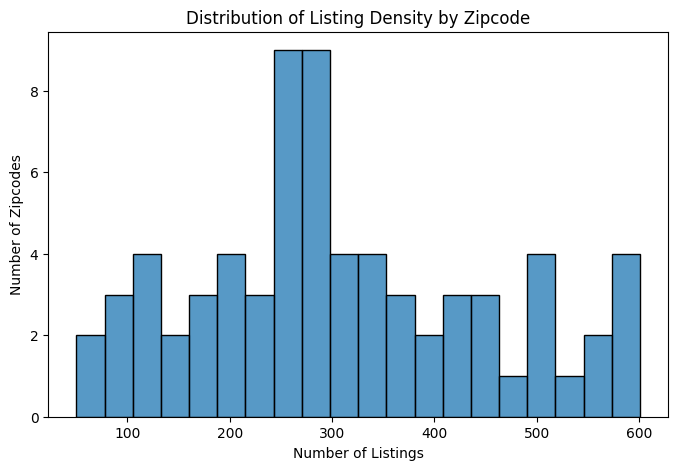

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(zipcode_counts["count"], bins=20)
plt.title("Distribution of Listing Density by Zipcode")
plt.xlabel("Number of Listings")
plt.ylabel("Number of Zipcodes")
plt.show()

### 2. Does the proximity to central area affect the price of the house?
**Hypothesis 2: The proximity has significant impact on the housing price.**

In [20]:
# Central zipcode definition (downtown or active area of Seattle, Bellevue, Renton/Tukwila)

central_zipcodes = [
    98101, 98104, 98121, 98174,  # Downtown, Pioneer Square, Belltown
    98102, 98112, 98122,          # Capitol Hill, First Hill, Central District
    98103, 98105, 98107, 98119,  # Fremont, Wallingford, U-District, Ballard, Queen Anne
    98144, 98108, 98118,          # Mount Baker, Beacon Hill, Columbia City
    98004, 98005, 98007,          # Downtown Bellevue, Wilburton, Crossroads
    98006, 98008,                  # Factoria, Newport, Lake Hills
    98055, 98056, 98057, 98059,  # Renton
    98188, 98168                   # Tukwila / SeaTac
]

In [21]:
# Flag whether each house falls within a defined central zipcode

df["is_central"] = df["zipcode"].isin(central_zipcodes)

In [22]:
# Relationship between central location and house prcie
#  
df.groupby("is_central")["price"].agg(["count", "mean", "median"])

,count,mean,median
is_central,,,
False,15663,504528.036455,430000.0
True,5933,634707.982977,525000.0


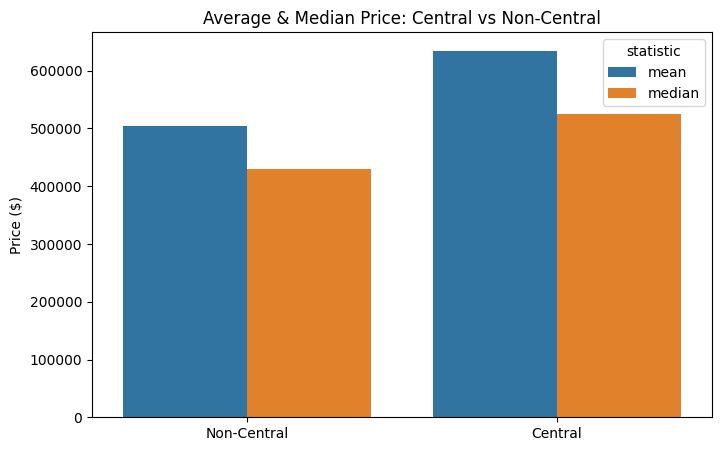

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

central_price = df.groupby("is_central")["price"].agg(["mean", "median"]).reset_index()
central_price_melted = central_price.melt(id_vars="is_central", var_name="statistic", value_name="price")

plt.figure(figsize=(8, 5))
sns.barplot(data=central_price_melted, x="is_central", y="price", hue="statistic")
plt.title("Average & Median Price: Central vs Non-Central")
plt.xlabel("")
plt.xticks([0, 1], ["Non-Central", "Central"])
plt.ylabel("Price ($)")
plt.show()

In [25]:
# Plot listings located in central zipcodes on a map of King County

central_df = df[df["is_central"] == True]

fig = px.scatter_mapbox(
    central_df,
    lat="lat",
    lon="long",
    title="Central Areas in King County",
    mapbox_style="carto-positron",
    zoom=8.5,
    opacity=0.4,
    color_discrete_sequence=["crimson"]
)
fig.update_layout(height=600)
fig.show()


C:\Users\ghsm0\AppData\Local\Temp\ipykernel_17344\3302400549.py:5: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### 3. Does the time of the year (season/month) affect the price of the house?
**Hypothesis 3: Specific season have both a higher number of listings and higher average/median prices compared to other seasons.**

In [ ]:
#1. creat a new column of sales counting based on month
df["sale_month"] = df["date"].dt.month

df.head()

,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,is_central,sale_month
0,2014-10-13,221900.0,7129300520,1,3.0,1.00,1180.0,5650.0,1.0,0.0,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,False,10
1,2014-12-09,538000.0,6414100192,2,3.0,2.25,2570.0,7242.0,2.0,0.0,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,False,12
2,2015-02-25,180000.0,5631500400,3,2.0,1.00,770.0,10000.0,1.0,0.0,...,0.0,1933,0.0,98028,47.7379,-122.233,2720.0,8062.0,False,2
3,2014-12-09,604000.0,2487200875,4,4.0,3.00,1960.0,5000.0,1.0,0.0,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,False,12
4,2015-02-18,510000.0,1954400510,5,3.0,2.00,1680.0,8080.0,1.0,0.0,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,False,2


In [34]:
#2. compare the housing price between months 
df.groupby("sale_month")["price"].agg(["count", "mean", "median"])

,count,mean,median
sale_month,,,
1,978,525963.251534,438500.0
2,1247,508520.051323,426500.0
3,1875,544057.683200,450000.0
4,2229,562215.615074,477000.0
5,2414,550849.746893,462000.0
6,2177,557496.437758,465000.0
7,2211,544892.161013,465000.0
8,1939,536655.212481,442200.0
9,1771,529723.517787,450000.0


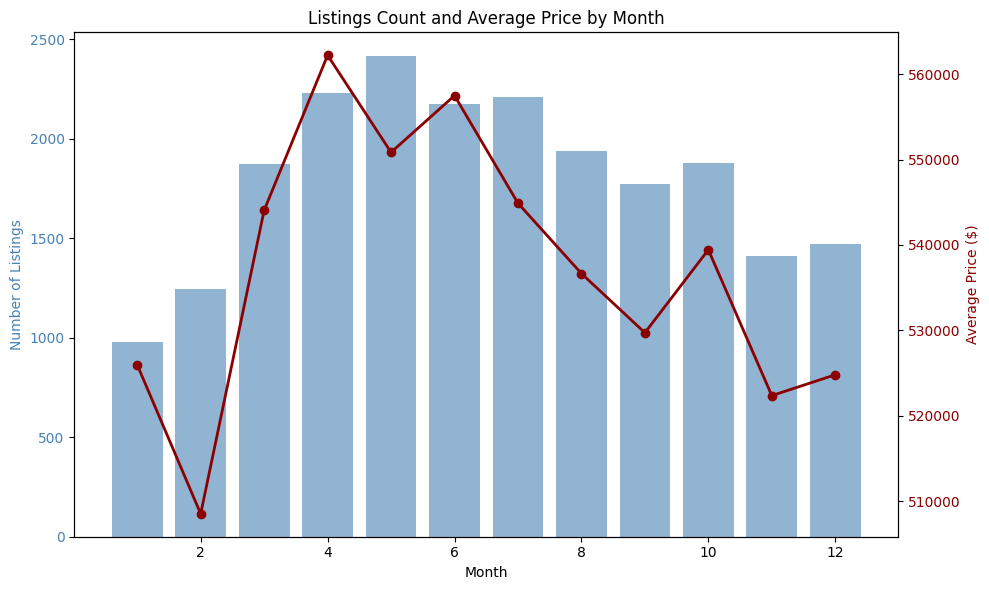

In [38]:
# Combine listing count (bar) and average price (line) by month on a dual-axis chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart: number of listings (left y-axis)
ax1.bar(monthly.index, monthly["count"], color="steelblue", alpha=0.6, label="Number of Listings")
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Listings", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Line chart: average price (mean, right y-axis)
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["mean"], color="darkred", marker="o", linewidth=2, label="Average Price")
ax2.set_ylabel("Average Price ($)", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")

plt.title("Listings Count and Average Price by Month")
fig.tight_layout()
plt.show()